In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Preprocessing

In [1]:
import os
import random
import math
import pathlib
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms, models, datasets, utils

from torch.optim.lr_scheduler import ReduceLROnPlateau, StepLR, CosineAnnealingLR

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

torch: 2.9.0+cu126
torchvision: 0.24.0+cu126
Device: cuda


In [2]:
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DATASET_ROOT = "/kaggle/input/alzheimers-dataset/MRI"
IMG_SIZE = (224, 224) 
BATCH_SIZE = 32
EPOCHS = 100
KFOLDS = 5              
TEST_SIZE = 0.1         
VAL_SIZE = 0.1
VAL_SIZE_WITHIN_TRAIN = 0.1  

WEIGHT_DECAY = 1e-4     
DROPOUT_RATE = 0.3
BASE_LR = 1e-3         

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
import pathlib
import pandas as pd

DATASET_ROOT = pathlib.Path("/kaggle/input/alzheimers-dataset/MRI")

filepaths = []
labels = []

for class_dir in sorted([p for p in DATASET_ROOT.iterdir() if p.is_dir()]):
    for img_path in class_dir.rglob("*.*"):
        if img_path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".gif"}:
            filepaths.append(str(img_path))
            labels.append(class_dir.name)

df = pd.DataFrame({"filepath": filepaths, "label": labels})
print(df.head())
print("Total images:", len(df), "| Classes:", df["label"].nunique())

class_names = sorted(df["label"].unique())

class_to_idx = {name: idx for idx, name in enumerate(class_names)}

print("\nClass names and indices:")
for idx, name in enumerate(class_names):
    print(f"{idx}: {name}")

                                            filepath          label
0  /kaggle/input/alzheimers-dataset/MRI/Mild Deme...  Mild Demented
1  /kaggle/input/alzheimers-dataset/MRI/Mild Deme...  Mild Demented
2  /kaggle/input/alzheimers-dataset/MRI/Mild Deme...  Mild Demented
3  /kaggle/input/alzheimers-dataset/MRI/Mild Deme...  Mild Demented
4  /kaggle/input/alzheimers-dataset/MRI/Mild Deme...  Mild Demented
Total images: 40000 | Classes: 4

Class names and indices:
0: Mild Demented
1: Moderate Demented
2: Non Demented
3: Very Mild Demented


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = df.sort_values(by=["label", "filepath"]).reset_index(drop=True)

le = LabelEncoder()
df["label_idx"] = le.fit_transform(df["label"])
class_names = list(le.classes_)
num_classes = len(class_names)
print("Classes:", class_names)

train_val_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    stratify=df["label_idx"],
    random_state=SEED,
    shuffle=True
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=VAL_SIZE,
    stratify=train_val_df["label_idx"],
    random_state=SEED,
    shuffle=True
)

print(f"{len(train_df)} train images | {len(val_df)} validation images | {len(test_df)} test images")

Classes: ['Mild Demented', 'Moderate Demented', 'Non Demented', 'Very Mild Demented']
32400 train images | 3600 validation images | 4000 test images


In [5]:
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torch
import random

class RandomBiasField:
    def __init__(self, bias_range=0.3):
        self.bias_range = bias_range

    def __call__(self, tensor):
        _, h, w = tensor.shape
        bias = torch.randn(1, h // 16, w // 16)
        bias = torch.nn.functional.interpolate(bias.unsqueeze(0), size=(h, w), mode='bilinear', align_corners=False)[0]
        bias = bias.squeeze(0)
        bias = (bias - bias.min()) / (bias.max() - bias.min() + 1e-8)
        bias = 1.0 + (bias - 0.5) * self.bias_range
        return torch.clamp(tensor * bias, 0, 1)


class AddGaussianNoise:
    def __init__(self, mean=0., std=0.01):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        return torch.clamp(tensor + torch.randn_like(tensor) * self.std + self.mean, 0, 1)


class RandomGammaCorrection:
    def __init__(self, gamma_range=(0.9, 1.1)):
        self.gamma_range = gamma_range

    def __call__(self, tensor):
        gamma = random.uniform(*self.gamma_range)
        return torch.pow(tensor, gamma)

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop((224, 224), scale=(0.9, 1.0)),
    transforms.RandomAffine(degrees=5, translate=(0.02, 0.02)),
    transforms.RandomHorizontalFlip(p=0.3),                     
    transforms.ToTensor(),                                       
    RandomBiasField(bias_range=0.25),                            
    AddGaussianNoise(mean=0., std=0.015),                        
    RandomGammaCorrection(gamma_range=(0.95, 1.05)),            
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

test_transforms = val_transforms

class MRIDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.filepaths = dataframe['filepath'].values
        self.labels = dataframe['label_idx'].values

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.filepaths[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

train_dataset = MRIDataset(train_df, transform=train_transforms)
val_dataset = MRIDataset(val_df, transform=val_transforms)
test_dataset = MRIDataset(test_df, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, drop_last=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

In [6]:
%cd /kaggle/working/
%mkdir Model

/kaggle/working


# VGG16

In [11]:
%cd /kaggle/working/Model
%mkdir VGG16

/kaggle/working/Model


Device: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


CustomClassifier(
  (backbone): VGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=True)


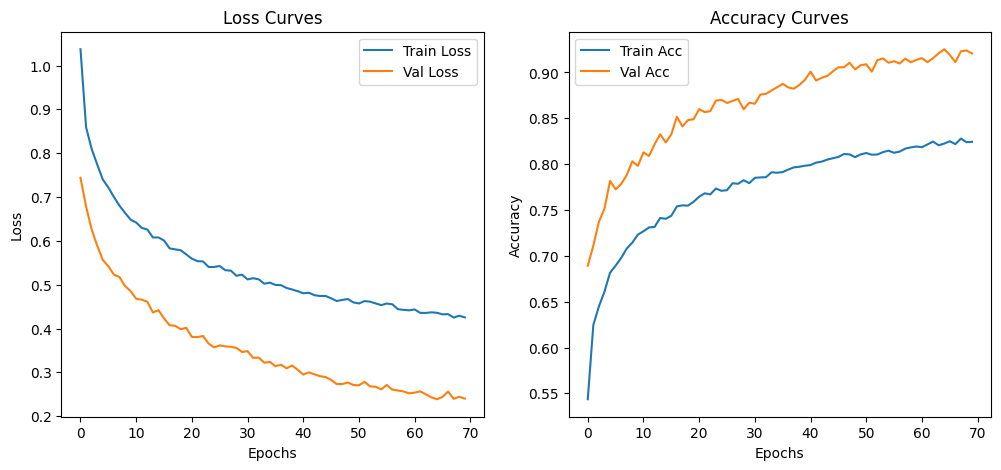

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
from torchvision import models

num_classes = 4
EPOCHS = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_PATH = "/kaggle/working/Model/VGG16/best_vgg16_full.pth"
SAVE_WEIGHTS_PATH = "/kaggle/working/Model/VGG16/best_vgg16_weights.pth"
print("Device:", device)


base_model = models.vgg16(pretrained=True)
for param in base_model.parameters():
    param.requires_grad = False


class CustomClassifier(nn.Module):
    def __init__(self, backbone, num_classes):
        super().__init__()
        self.backbone = backbone
        self.backbone.classifier = nn.Identity()

        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        in_features = 512

        self.classifier = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Dropout(0.4),
            nn.Linear(in_features, 512, bias=False),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),

            nn.Linear(512, 128, bias=False),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(128),
            nn.Dropout(0.2),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.backbone.features(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

model = CustomClassifier(base_model, num_classes=num_classes)
model = model.float().to(device)
print(model)

criterion = nn.CrossEntropyLoss()
l2_layers = [model.classifier[1], model.classifier[5]]
params_with_l2 = [p for layer in l2_layers for p in layer.parameters()]
params_with_l2_ids = set(id(p) for p in params_with_l2)
params_without_l2 = [p for p in model.parameters() if id(p) not in params_with_l2_ids]

optimizer = optim.Adam([
    {'params': params_with_l2, 'weight_decay': 1e-4},
    {'params': params_without_l2, 'weight_decay': 0.0}
], lr=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6
)

class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-3, save_path=SAVE_PATH, save_weights_path=SAVE_WEIGHTS_PATH):
        self.patience = patience
        self.min_delta = min_delta
        self.save_path = save_path
        self.save_weights_path = save_weights_path
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model, self.save_path)
            torch.save(model.state_dict(), self.save_weights_path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

early_stopping = EarlyStopping()


from torch.amp import autocast, GradScaler
scaler = GradScaler()


train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(EPOCHS):
    print(f"\n=== Epoch {epoch+1}/{EPOCHS} ===")
    model.train()
    running_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:  # train_loader must be defined
        images, labels = images.to(device), labels.to(device, dtype=torch.long)
        optimizer.zero_grad()

        with autocast(device_type=device.type):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:  # val_loader must be defined
            images, labels = images.to(device), labels.to(device, dtype=torch.long)
            with autocast(device_type=device.type):
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    scheduler.step(val_loss)
    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print("⏹ Early stopping triggered!")
        break

model.load_state_dict(torch.load(SAVE_WEIGHTS_PATH, map_location=device))
model.to(device)
print("✅ Loaded best DS-ViT model weights.")

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend(); plt.title("Loss Curves")

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.legend(); plt.title("Accuracy Curves")
plt.show()

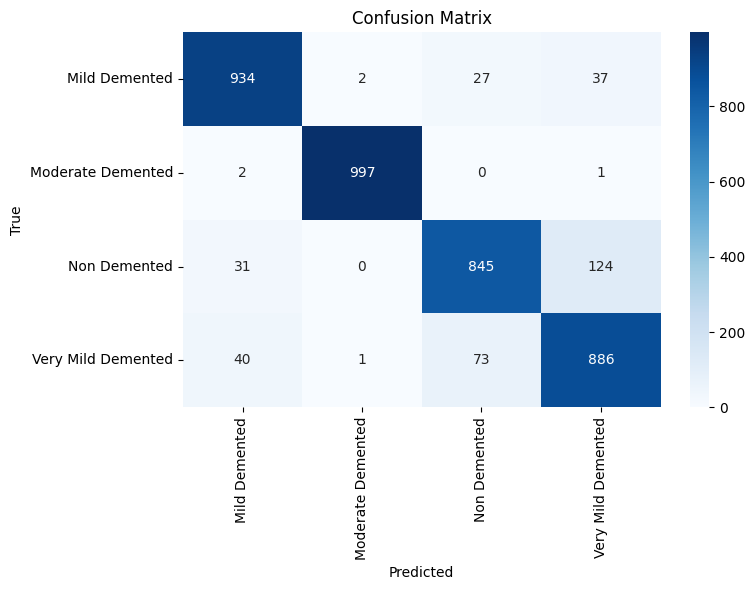


================ Overall Test Metrics ================
Accuracy               : 0.9155
Precision (Macro)      : 0.9160
Recall (Macro)         : 0.9155
F1-Score (Macro)       : 0.9155

================ Class-wise Metrics ================
             Class  Sensitivity (Recall)  Specificity  Precision  False Positive Rate  False Negative Rate      NPV  F1 Score
     Mild Demented                 0.934     0.975667   0.927507             0.024333                0.066 0.977949  0.930742
 Moderate Demented                 0.997     0.999000   0.997000             0.001000                0.003 0.999000  0.997000
      Non Demented                 0.845     0.966667   0.894180             0.033333                0.155 0.949264  0.868895
Very Mild Demented                 0.886     0.946000   0.845420             0.054000                0.114 0.961382  0.865234

================ Classification Report ================
                    precision    recall  f1-score   support

     Mild Deme

In [13]:
import torch
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()

all_preds = []
all_labels = []

filepaths = test_df['filepath'].values

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device, dtype=torch.long)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

overall_acc = accuracy_score(all_labels, all_preds)

overall_precision_macro = precision_score(
    all_labels, all_preds, average='macro', zero_division=0
)
overall_recall_macro = recall_score(
    all_labels, all_preds, average='macro', zero_division=0
)
overall_f1_macro = f1_score(
    all_labels, all_preds, average='macro', zero_division=0
)

print("\n================ Overall Test Metrics ================")
print(f"Accuracy               : {overall_acc:.4f}")
print(f"Precision (Macro)      : {overall_precision_macro:.4f}")
print(f"Recall (Macro)         : {overall_recall_macro:.4f}")
print(f"F1-Score (Macro)       : {overall_f1_macro:.4f}")


metrics = []

for i, class_name in enumerate(class_names):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - (TP + FP + FN)

    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    precision   = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    fpr         = FP / (FP + TN) if (FP + TN) > 0 else 0.0
    fnr         = FN / (FN + TP) if (FN + TP) > 0 else 0.0
    npv         = TN / (TN + FN) if (TN + FN) > 0 else 0.0
    f1          = 2 * TP / (2 * TP + FP + FN) if (2*TP + FP + FN) > 0 else 0.0

    metrics.append([
        class_name,
        sensitivity,
        specificity,
        precision,
        fpr,
        fnr,
        npv,
        f1
    ])

metrics_df = pd.DataFrame(metrics, columns=[
    "Class",
    "Sensitivity (Recall)",
    "Specificity",
    "Precision",
    "False Positive Rate",
    "False Negative Rate",
    "NPV",
    "F1 Score"
])

print("\n================ Class-wise Metrics ================")
print(metrics_df.to_string(index=False))


print("\n================ Classification Report ================")
print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4
))


results_df = pd.DataFrame({
    "filepath": filepaths,
    "true_label": [class_names[i] for i in all_labels],
    "pred_label": [class_names[i] for i in all_preds]
})

overall_metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision (Macro)",
        "Recall (Macro)",
        "F1-Score (Macro)"
    ],
    "Value": [
        overall_acc,
        overall_precision_macro,
        overall_recall_macro,
        overall_f1_macro
    ]
})

results_df.to_csv("test_predictions.csv", index=False)
metrics_df.to_csv("test_classwise_metrics.csv", index=False)
overall_metrics_df.to_csv("test_overall_metrics.csv", index=False)

print("\n✅ Predictions saved to 'test_predictions.csv'")
print("✅ Class-wise metrics saved to 'test_classwise_metrics.csv'")
print("✅ Overall metrics saved to 'test_overall_metrics.csv'")

# ViT-Base/16

In [7]:
%cd /kaggle/working/Model
%mkdir ViT

/kaggle/working/Model


Device: cuda

=== Epoch 1/100 ===
Train Loss: 0.8703 | Train Acc: 0.6172 | Val Loss: 0.6342 | Val Acc: 0.7161

=== Epoch 2/100 ===
Train Loss: 0.7428 | Train Acc: 0.6759 | Val Loss: 0.5870 | Val Acc: 0.7442

=== Epoch 3/100 ===
Train Loss: 0.6955 | Train Acc: 0.6978 | Val Loss: 0.5506 | Val Acc: 0.7711

=== Epoch 4/100 ===
Train Loss: 0.6663 | Train Acc: 0.7104 | Val Loss: 0.5192 | Val Acc: 0.7900

=== Epoch 5/100 ===
Train Loss: 0.6377 | Train Acc: 0.7267 | Val Loss: 0.4809 | Val Acc: 0.8117

=== Epoch 6/100 ===
Train Loss: 0.6245 | Train Acc: 0.7342 | Val Loss: 0.4640 | Val Acc: 0.8197

=== Epoch 7/100 ===
Train Loss: 0.6029 | Train Acc: 0.7437 | Val Loss: 0.4386 | Val Acc: 0.8314

=== Epoch 8/100 ===
Train Loss: 0.5845 | Train Acc: 0.7501 | Val Loss: 0.4230 | Val Acc: 0.8356

=== Epoch 9/100 ===
Train Loss: 0.5750 | Train Acc: 0.7552 | Val Loss: 0.4162 | Val Acc: 0.8389

=== Epoch 10/100 ===
Train Loss: 0.5634 | Train Acc: 0.7648 | Val Loss: 0.3979 | Val Acc: 0.8400

=== Epoch 11/10

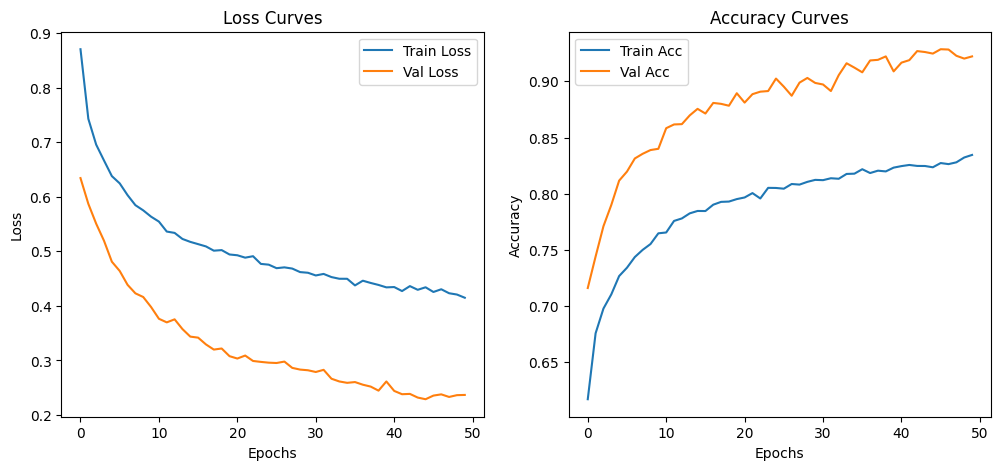

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
from torchvision import models

num_classes = 4
EPOCHS = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_PATH = "/kaggle/working/Model/ViT/best_vit_full.pth"
SAVE_WEIGHTS_PATH = "/kaggle/working/Model/ViT/best_vit_weights.pth"
print("Device:", device)

base_model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
for param in base_model.parameters():
    param.requires_grad = False


class CustomClassifierViT(nn.Module):
    def __init__(self, backbone, num_classes):
        super().__init__()
        self.backbone = backbone
        self.backbone.heads = nn.Identity()

        in_features = backbone.hidden_dim

        self.classifier = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Dropout(0.4),
            nn.Linear(in_features, 512, bias=False),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),

            nn.Linear(512, 128, bias=False),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(128),
            nn.Dropout(0.2),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.classifier(x)
        return x

model = CustomClassifierViT(base_model, num_classes=num_classes)
model = model.float().to(device)

criterion = nn.CrossEntropyLoss()
l2_layers = [model.classifier[1], model.classifier[5]]
params_with_l2 = [p for layer in l2_layers for p in layer.parameters()]
params_with_l2_ids = set(id(p) for p in params_with_l2)
params_without_l2 = [p for p in model.parameters() if id(p) not in params_with_l2_ids]

optimizer = optim.Adam([
    {'params': params_with_l2, 'weight_decay': 1e-4},
    {'params': params_without_l2, 'weight_decay': 0.0}
], lr=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6
)

class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-3, save_path=SAVE_PATH, save_weights_path=SAVE_WEIGHTS_PATH):
        self.patience = patience
        self.min_delta = min_delta
        self.save_path = save_path
        self.save_weights_path = save_weights_path
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model, self.save_path)
            torch.save(model.state_dict(), self.save_weights_path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

early_stopping = EarlyStopping()


from torch.amp import autocast, GradScaler
scaler = GradScaler()


train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(EPOCHS):
    print(f"\n=== Epoch {epoch+1}/{EPOCHS} ===")
    model.train()
    running_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:  # train_loader must be defined
        images, labels = images.to(device), labels.to(device, dtype=torch.long)
        optimizer.zero_grad()

        with autocast(device_type=device.type):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device, dtype=torch.long)
            with autocast(device_type=device.type):
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    scheduler.step(val_loss)
    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print("⏹ Early stopping triggered!")
        break

model.load_state_dict(torch.load(SAVE_WEIGHTS_PATH, map_location=device))
model.to(device)
print("✅ Loaded best DS-ViT model weights.")

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend(); plt.title("Loss Curves")

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.legend(); plt.title("Accuracy Curves")
plt.show()

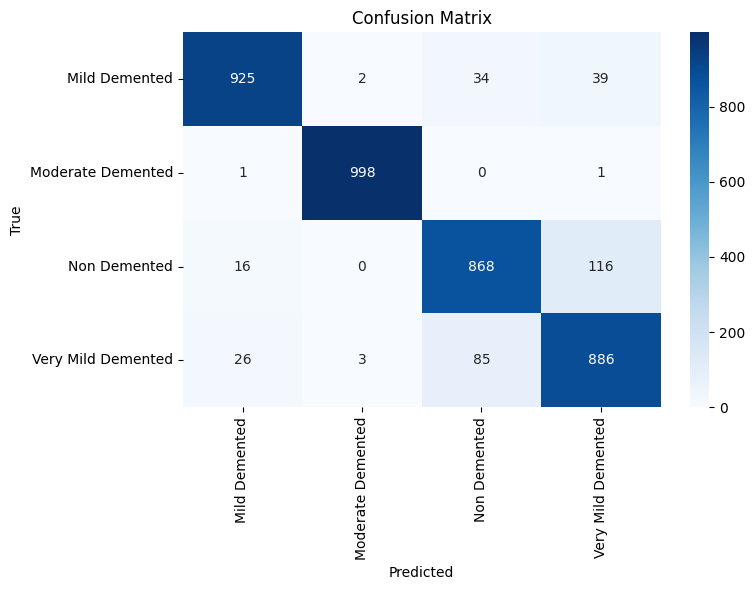


================ Overall Test Metrics ================
Accuracy               : 0.9193
Precision (Macro)      : 0.9201
Recall (Macro)         : 0.9193
F1-Score (Macro)       : 0.9195

================ Class-wise Metrics ================
             Class  Sensitivity (Recall)  Specificity  Precision  False Positive Rate  False Negative Rate      NPV  F1 Score
     Mild Demented                 0.925     0.985667   0.955579             0.014333                0.075 0.975264  0.940041
 Moderate Demented                 0.998     0.998333   0.995015             0.001667                0.002 0.999333  0.996505
      Non Demented                 0.868     0.960333   0.879433             0.039667                0.132 0.956190  0.873679
Very Mild Demented                 0.886     0.948000   0.850288             0.052000                0.114 0.961460  0.867777

================ Classification Report ================
                    precision    recall  f1-score   support

     Mild Deme

In [14]:
import torch
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()

all_preds = []
all_labels = []

filepaths = test_df['filepath'].values

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device, dtype=torch.long)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

overall_acc = accuracy_score(all_labels, all_preds)

overall_precision_macro = precision_score(
    all_labels, all_preds, average='macro', zero_division=0
)
overall_recall_macro = recall_score(
    all_labels, all_preds, average='macro', zero_division=0
)
overall_f1_macro = f1_score(
    all_labels, all_preds, average='macro', zero_division=0
)

print("\n================ Overall Test Metrics ================")
print(f"Accuracy               : {overall_acc:.4f}")
print(f"Precision (Macro)      : {overall_precision_macro:.4f}")
print(f"Recall (Macro)         : {overall_recall_macro:.4f}")
print(f"F1-Score (Macro)       : {overall_f1_macro:.4f}")


metrics = []

for i, class_name in enumerate(class_names):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - (TP + FP + FN)

    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    precision   = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    fpr         = FP / (FP + TN) if (FP + TN) > 0 else 0.0
    fnr         = FN / (FN + TP) if (FN + TP) > 0 else 0.0
    npv         = TN / (TN + FN) if (TN + FN) > 0 else 0.0
    f1          = 2 * TP / (2 * TP + FP + FN) if (2*TP + FP + FN) > 0 else 0.0

    metrics.append([
        class_name,
        sensitivity,
        specificity,
        precision,
        fpr,
        fnr,
        npv,
        f1
    ])

metrics_df = pd.DataFrame(metrics, columns=[
    "Class",
    "Sensitivity (Recall)",
    "Specificity",
    "Precision",
    "False Positive Rate",
    "False Negative Rate",
    "NPV",
    "F1 Score"
])

print("\n================ Class-wise Metrics ================")
print(metrics_df.to_string(index=False))

print("\n================ Classification Report ================")
print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4
))


results_df = pd.DataFrame({
    "filepath": filepaths,
    "true_label": [class_names[i] for i in all_labels],
    "pred_label": [class_names[i] for i in all_preds]
})

overall_metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision (Macro)",
        "Recall (Macro)",
        "F1-Score (Macro)"
    ],
    "Value": [
        overall_acc,
        overall_precision_macro,
        overall_recall_macro,
        overall_f1_macro
    ]
})

results_df.to_csv("test_predictions.csv", index=False)
metrics_df.to_csv("test_classwise_metrics.csv", index=False)
overall_metrics_df.to_csv("test_overall_metrics.csv", index=False)

print("\n✅ Predictions saved to 'test_predictions.csv'")
print("✅ Class-wise metrics saved to 'test_classwise_metrics.csv'")
print("✅ Overall metrics saved to 'test_overall_metrics.csv'")

# DS-ViT Model

In [26]:
%cd /kaggle/working/Model
%mkdir ds-vit

/kaggle/working/Model


Device: cuda
✅ Loaded custom VGG16 weights (26 layers)
✅ DS-ViT ready with 16×16 patches and custom VGG16 backbone.

=== Epoch 1/100 ===
Train Loss: 1.0609 | Train Acc: 0.5195 | Val Loss: 1.2757 | Val Acc: 0.4536

=== Epoch 2/100 ===
Train Loss: 0.8117 | Train Acc: 0.6331 | Val Loss: 0.9125 | Val Acc: 0.6406

=== Epoch 3/100 ===
Train Loss: 0.7412 | Train Acc: 0.6709 | Val Loss: 0.6287 | Val Acc: 0.7206

=== Epoch 4/100 ===
Train Loss: 0.6914 | Train Acc: 0.6944 | Val Loss: 0.7938 | Val Acc: 0.6639

=== Epoch 5/100 ===
Train Loss: 0.6588 | Train Acc: 0.7117 | Val Loss: 0.7413 | Val Acc: 0.6853

=== Epoch 6/100 ===
Train Loss: 0.6252 | Train Acc: 0.7282 | Val Loss: 0.6310 | Val Acc: 0.7378

=== Epoch 7/100 ===
Train Loss: 0.6042 | Train Acc: 0.7389 | Val Loss: 0.5287 | Val Acc: 0.7658

=== Epoch 8/100 ===
Train Loss: 0.5684 | Train Acc: 0.7569 | Val Loss: 0.5129 | Val Acc: 0.7819

=== Epoch 9/100 ===
Train Loss: 0.5435 | Train Acc: 0.7682 | Val Loss: 0.5087 | Val Acc: 0.7869

=== Epoch 

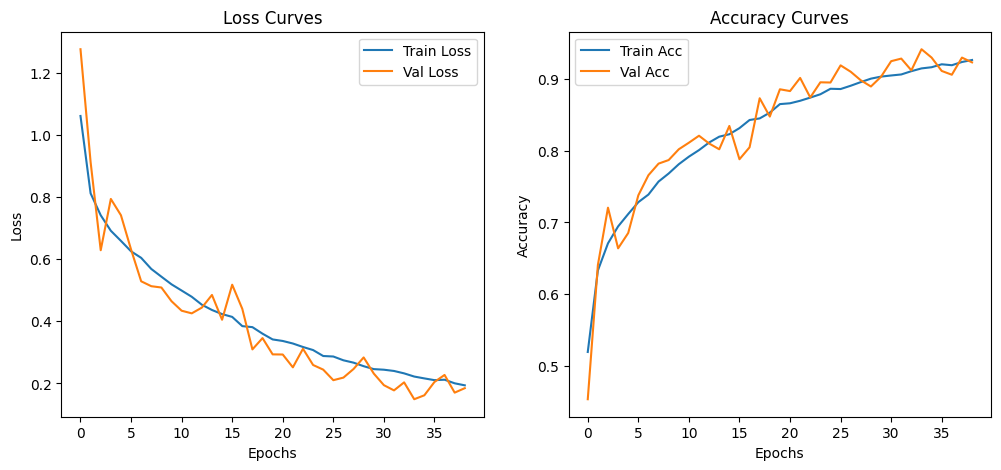

In [28]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

SAVE_PATH = "/kaggle/working/Model/ds-vit/best_yet_full.pth"
SAVE_WEIGHTS_PATH = "/kaggle/working/Model/ds-vit/best_yet_weights.pth"
num_classes = 4
EPOCHS = 100

weights_path = "/kaggle/working/Model/VGG16/best_vgg16_weights.pth"

class VGG16Backbone16Patch(nn.Module):
    def __init__(self, weights_path=None):
        super().__init__()
        base_model = models.vgg16(pretrained=True)
        base_model.classifier = nn.Identity()

        self.features = nn.Sequential(*list(base_model.features.children())[:17])

        for p in self.features.parameters():
            p.requires_grad = False

        if weights_path:
            try:
                state_dict = torch.load(weights_path, map_location='cpu')

                new_state_dict = {}
                for k, v in state_dict.items():
                    if k.startswith('features.'):
                        new_state_dict[k] = v
                    elif k.startswith('backbone.features.'):
                        new_state_dict[k.replace('backbone.features.', '')] = v
                    elif k.startswith('cnn.features.'):
                        new_state_dict[k.replace('cnn.features.', '')] = v
                    else:
                        continue

                missing, unexpected = self.features.load_state_dict(new_state_dict, strict=False)
                print(f"✅ Loaded custom VGG16 weights ({len(new_state_dict)} layers)")

            except Exception as e:
                print("Using pretrained ImageNet VGG16 features instead.")

    def forward(self, x): 
        return self.features(x)


class MultiHeadSelfAttention(nn.Module):
    def __init__(self, dim, num_heads=8, dropout=0.2):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.ln1 = nn.LayerNorm(dim)
        self.ln2 = nn.LayerNorm(dim)
        self.ffn = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Linear(dim * 4, dim)
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        attn_out, attn_weights = self.attn(x, x, x, need_weights=True)
        x = self.ln1(x + self.dropout(attn_out))
        ffn_out = self.ffn(x)
        x = self.ln2(x + self.dropout(ffn_out))
        return x, attn_weights


class PositionalEncoding(nn.Module):
    def __init__(self, dim, max_len=2048):
        super().__init__()
        self.pe = nn.Parameter(torch.randn(1, max_len, dim))

    def forward(self, x):
        N = x.size(1)
        return x + self.pe[:, :N, :].to(x.device)


class DualStageViT(nn.Module):
    def __init__(self, cnn_backbone, num_classes=4, embed_dim=512, num_heads=8, patch_size=16):
        super().__init__()
        self.cnn = cnn_backbone
        self.patch_size = patch_size
        self.embed_dim = embed_dim

        # Stage 1: Intra-patch attention
        self.local_attn = MultiHeadSelfAttention(embed_dim, num_heads)

        # Stage 2: Inter-patch attention
        self.global_attn = MultiHeadSelfAttention(embed_dim, num_heads)

        self.pos_global = PositionalEncoding(embed_dim)

        self.gap = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(embed_dim),
            nn.Dropout(0.4),
            nn.Linear(embed_dim, 512, bias=False),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),
            nn.Linear(512, 128, bias=False),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(128),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        B, C, H, W = x.shape
        p = self.patch_size

        patches = x.unfold(2, p, p).unfold(3, p, p)
        num_H, num_W = patches.shape[2], patches.shape[3]
        patches = patches.contiguous().view(B, C, num_H * num_W, p, p)
        patches = patches.permute(0, 2, 1, 3, 4)
        patches = patches.reshape(B * num_H * num_W, C, p, p)

        feat_maps = self.cnn(patches) 

        Bn, Cn, h, w = feat_maps.shape

        # Stage 1: Intra-Patch Attention
        local_tokens = feat_maps.flatten(2).transpose(1, 2)

        local_tokens, _ = self.local_attn(local_tokens)

        patch_embeddings = local_tokens.mean(dim=1)

        patch_embeddings = patch_embeddings.view(B, num_H * num_W, -1)

        # Stage 2: Inter-Patch Attention
        global_tokens = self.pos_global(patch_embeddings)
        global_tokens, _ = self.global_attn(global_tokens)

        x = self.gap(global_tokens.transpose(1, 2)).squeeze(-1)
        
        x = self.classifier(x)

        return x

cnn_backbone = VGG16Backbone16Patch(weights_path=weights_path)

model = DualStageViT(
    cnn_backbone=cnn_backbone,
    num_classes=num_classes,
    embed_dim=256,
    num_heads=4,
    patch_size=16
).to(device)

print("✅ DS-ViT ready with 16×16 patches and custom VGG16 backbone.")



criterion = nn.CrossEntropyLoss()
l2_layers = [model.classifier[1], model.classifier[5]]
params_with_l2 = [p for layer in l2_layers for p in layer.parameters()]
params_with_l2_ids = set(id(p) for p in params_with_l2)
params_without_l2 = [p for p in model.parameters() if id(p) not in params_with_l2_ids]

optimizer = optim.Adam([
    {'params': params_with_l2, 'weight_decay': 1e-4},
    {'params': params_without_l2, 'weight_decay': 0.0}
], lr=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6
)

class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-3, save_path=SAVE_PATH, save_weights_path=SAVE_WEIGHTS_PATH):
        self.patience = patience
        self.min_delta = min_delta
        self.save_path = save_path
        self.save_weights_path = save_weights_path
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model, self.save_path)
            torch.save(model.state_dict(), self.save_weights_path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

early_stopping = EarlyStopping()

from torch.amp import autocast, GradScaler
scaler = GradScaler()

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(EPOCHS):
    print(f"\n=== Epoch {epoch+1}/{EPOCHS} ===")
    model.train()
    running_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device, dtype=torch.long)
        optimizer.zero_grad()

        with autocast(device_type=device.type):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total


    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:  # val_loader must be defined
            images, labels = images.to(device), labels.to(device, dtype=torch.long)
            with autocast(device_type=device.type):
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    scheduler.step(val_loss)
    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print("⏹ Early stopping triggered!")
        break

model.load_state_dict(torch.load(SAVE_WEIGHTS_PATH, map_location=device))
model.to(device)
print("✅ Loaded best DS-ViT model weights.")

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend(); plt.title("Loss Curves")

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.legend(); plt.title("Accuracy Curves")
plt.show()

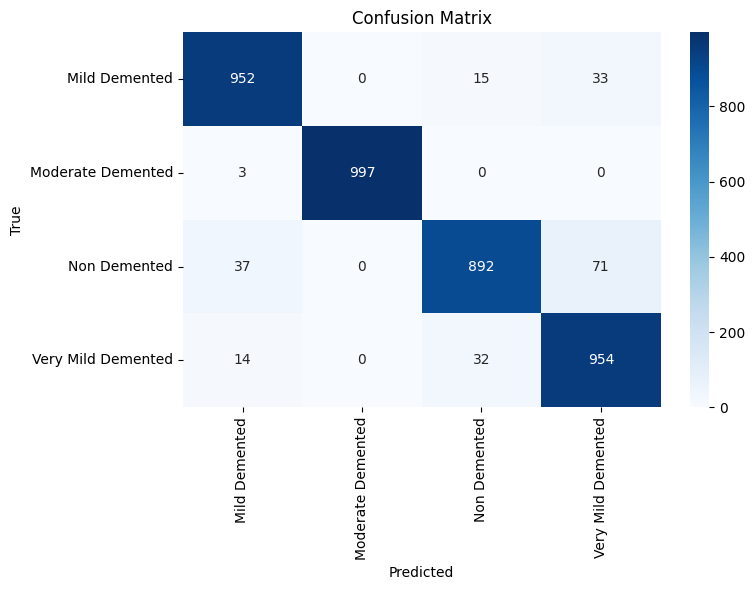


================ Overall Test Metrics ================
Accuracy               : 0.9487
Precision (Macro)      : 0.9495
Recall (Macro)         : 0.9487
F1-Score (Macro)       : 0.9487

================ Class-wise Metrics ================
             Class  Sensitivity (Recall)  Specificity  Precision  False Positive Rate  False Negative Rate      NPV  F1 Score
     Mild Demented                 0.952     0.982000   0.946322             0.018000                0.048 0.983968  0.949153
 Moderate Demented                 0.997     1.000000   1.000000             0.000000                0.003 0.999001  0.998498
      Non Demented                 0.892     0.984333   0.949947             0.015667                0.108 0.964717  0.920062
Very Mild Demented                 0.954     0.965333   0.901701             0.034667                0.046 0.984364  0.927114

================ Classification Report ================
                    precision    recall  f1-score   support

     Mild Deme

In [29]:
import torch
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()

all_preds = []
all_labels = []

filepaths = test_df['filepath'].values

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device, dtype=torch.long)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)


cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


overall_acc = accuracy_score(all_labels, all_preds)

overall_precision_macro = precision_score(
    all_labels, all_preds, average='macro', zero_division=0
)
overall_recall_macro = recall_score(
    all_labels, all_preds, average='macro', zero_division=0
)
overall_f1_macro = f1_score(
    all_labels, all_preds, average='macro', zero_division=0
)

print("\n================ Overall Test Metrics ================")
print(f"Accuracy               : {overall_acc:.4f}")
print(f"Precision (Macro)      : {overall_precision_macro:.4f}")
print(f"Recall (Macro)         : {overall_recall_macro:.4f}")
print(f"F1-Score (Macro)       : {overall_f1_macro:.4f}")


metrics = []

for i, class_name in enumerate(class_names):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - (TP + FP + FN)

    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    precision   = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    fpr         = FP / (FP + TN) if (FP + TN) > 0 else 0.0
    fnr         = FN / (FN + TP) if (FN + TP) > 0 else 0.0
    npv         = TN / (TN + FN) if (TN + FN) > 0 else 0.0
    f1          = 2 * TP / (2 * TP + FP + FN) if (2*TP + FP + FN) > 0 else 0.0

    metrics.append([
        class_name,
        sensitivity,
        specificity,
        precision,
        fpr,
        fnr,
        npv,
        f1
    ])

metrics_df = pd.DataFrame(metrics, columns=[
    "Class",
    "Sensitivity (Recall)",
    "Specificity",
    "Precision",
    "False Positive Rate",
    "False Negative Rate",
    "NPV",
    "F1 Score"
])

print("\n================ Class-wise Metrics ================")
print(metrics_df.to_string(index=False))


print("\n================ Classification Report ================")
print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4
))


results_df = pd.DataFrame({
    "filepath": filepaths,
    "true_label": [class_names[i] for i in all_labels],
    "pred_label": [class_names[i] for i in all_preds]
})

overall_metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision (Macro)",
        "Recall (Macro)",
        "F1-Score (Macro)"
    ],
    "Value": [
        overall_acc,
        overall_precision_macro,
        overall_recall_macro,
        overall_f1_macro
    ]
})

results_df.to_csv("test_predictions.csv", index=False)
metrics_df.to_csv("test_classwise_metrics.csv", index=False)
overall_metrics_df.to_csv("test_overall_metrics.csv", index=False)

print("\n✅ Predictions saved to 'test_predictions.csv'")
print("✅ Class-wise metrics saved to 'test_classwise_metrics.csv'")
print("✅ Overall metrics saved to 'test_overall_metrics.csv'")

# InceptionV3

In [15]:
%cd /kaggle/working/Model
%mkdir InceptionV3

/kaggle/working/Model


In [17]:
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torch
import random

class RandomBiasField:
    def __init__(self, bias_range=0.3):
        self.bias_range = bias_range

    def __call__(self, tensor):
        _, h, w = tensor.shape
        bias = torch.randn(1, h // 16, w // 16)
        bias = torch.nn.functional.interpolate(bias.unsqueeze(0), size=(h, w), mode='bilinear', align_corners=False)[0]
        bias = bias.squeeze(0)
        bias = (bias - bias.min()) / (bias.max() - bias.min() + 1e-8)
        bias = 1.0 + (bias - 0.5) * self.bias_range
        return torch.clamp(tensor * bias, 0, 1)


class AddGaussianNoise:
    def __init__(self, mean=0., std=0.01):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        return torch.clamp(tensor + torch.randn_like(tensor) * self.std + self.mean, 0, 1)


class RandomGammaCorrection:
    def __init__(self, gamma_range=(0.9, 1.1)):
        self.gamma_range = gamma_range

    def __call__(self, tensor):
        gamma = random.uniform(*self.gamma_range)
        return torch.pow(tensor, gamma)


imagenet_normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

train_transforms = transforms.Compose([
    transforms.Resize((320, 320)),
    transforms.RandomResizedCrop((299, 299), scale=(0.9, 1.0)),
    transforms.RandomAffine(degrees=5, translate=(0.02, 0.02)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(),
    RandomBiasField(bias_range=0.25),
    AddGaussianNoise(mean=0., std=0.015),
    RandomGammaCorrection(gamma_range=(0.95, 1.05)),
    imagenet_normalize
])

val_transforms = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    imagenet_normalize
])

test_transforms = val_transforms

class MRIDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.filepaths = dataframe['filepath'].values
        self.labels = dataframe['label_idx'].values

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.filepaths[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


train_dataset = MRIDataset(train_df, transform=train_transforms)
val_dataset = MRIDataset(val_df, transform=val_transforms)
test_dataset = MRIDataset(test_df, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, drop_last=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

Device: cuda

=== Epoch 1/100 ===
Train Loss: 4.6127 | Train Acc: 0.3985 | Val Loss: 1.5051 | Val Acc: 0.2803

=== Epoch 2/100 ===
Train Loss: 4.5158 | Train Acc: 0.4486 | Val Loss: 1.4843 | Val Acc: 0.2708

=== Epoch 3/100 ===
Train Loss: 4.4899 | Train Acc: 0.4629 | Val Loss: 1.5068 | Val Acc: 0.2581

=== Epoch 4/100 ===
Train Loss: 4.4698 | Train Acc: 0.4763 | Val Loss: 1.5034 | Val Acc: 0.2678

=== Epoch 5/100 ===
Train Loss: 4.4574 | Train Acc: 0.4819 | Val Loss: 1.5145 | Val Acc: 0.2644

=== Epoch 6/100 ===
Train Loss: 4.4498 | Train Acc: 0.4843 | Val Loss: 1.5003 | Val Acc: 0.2789

=== Epoch 7/100 ===
Train Loss: 4.4374 | Train Acc: 0.4937 | Val Loss: 1.4828 | Val Acc: 0.2572

=== Epoch 8/100 ===
Train Loss: 4.4276 | Train Acc: 0.4996 | Val Loss: 1.4819 | Val Acc: 0.2619

=== Epoch 9/100 ===
Train Loss: 4.4256 | Train Acc: 0.5014 | Val Loss: 1.4831 | Val Acc: 0.2617

=== Epoch 10/100 ===
Train Loss: 4.4102 | Train Acc: 0.5075 | Val Loss: 1.4931 | Val Acc: 0.2578

=== Epoch 11/10

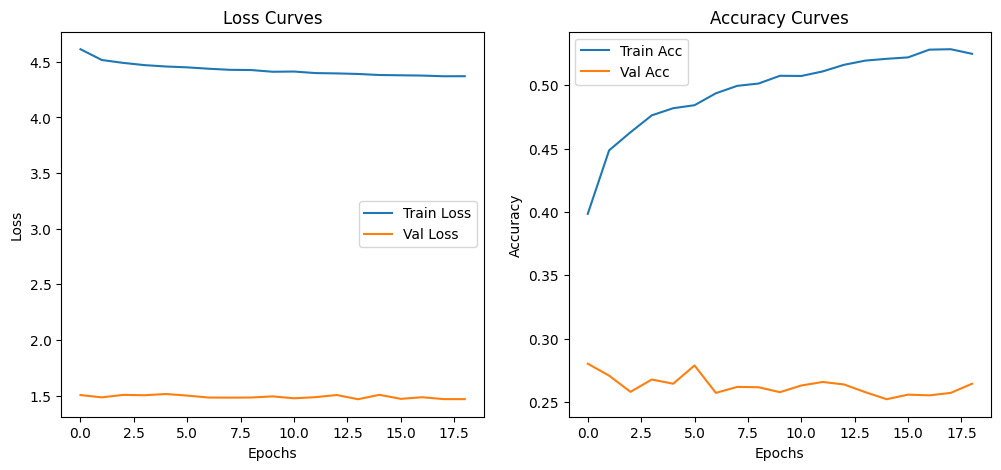

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
from torchvision import models

num_classes = 4
EPOCHS = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_PATH = "/kaggle/working/Model/InceptionV3/best_inceptionv3_full.pth"
SAVE_WEIGHTS_PATH = "/kaggle/working/Model/InceptionV3/best_inceptionv3_weights.pth"

print("Device:", device)

from torchvision.models import inception_v3, Inception_V3_Weights

weights = Inception_V3_Weights.DEFAULT
base_model = inception_v3(weights=weights, aux_logits=True)

for param in base_model.parameters():
    param.requires_grad = False

class CustomInceptionV3(nn.Module):
    def __init__(self, backbone, num_classes):
        super().__init__()
        self.backbone = backbone
        self.backbone.fc = nn.Identity()
        in_features = 2048
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Dropout(0.4),
            nn.Linear(in_features, 512, bias=False),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),
            nn.Linear(512, 128, bias=False),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(128),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        if self.training:
            x, aux = self.backbone(x)
            x = self.classifier(x)
            return x, aux
        else:
            x = self.backbone(x)
            if isinstance(x, tuple):
                x = x[0]
            x = self.classifier(x)
            return x

model = CustomInceptionV3(base_model, num_classes=num_classes)
model = model.float().to(device)

criterion = nn.CrossEntropyLoss()
l2_layers = [model.classifier[1], model.classifier[5]]
params_with_l2 = [p for layer in l2_layers for p in layer.parameters()]
params_with_l2_ids = set(id(p) for p in params_with_l2)
params_without_l2 = [p for p in model.parameters() if id(p) not in params_with_l2_ids]

optimizer = optim.Adam([
    {'params': params_with_l2, 'weight_decay': 1e-4},
    {'params': params_without_l2, 'weight_decay': 0.0}
], lr=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6
)

class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-3, save_path=SAVE_PATH, save_weights_path=SAVE_WEIGHTS_PATH):
        self.patience = patience
        self.min_delta = min_delta
        self.save_path = save_path
        self.save_weights_path = save_weights_path
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model, self.save_path)
            torch.save(model.state_dict(), self.save_weights_path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

early_stopping = EarlyStopping()


from torch.amp import autocast, GradScaler
scaler = GradScaler()


train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(EPOCHS):
    print(f"\n=== Epoch {epoch+1}/{EPOCHS} ===")
    model.train()
    running_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device, dtype=torch.long)
        optimizer.zero_grad()
    
        with autocast(device_type=device.type):
            outputs, aux_outputs = model(images)
            loss1 = criterion(outputs, labels)
            loss2 = criterion(aux_outputs, labels)
            loss = loss1 + 0.4 * loss2
    
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
    
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device, dtype=torch.long)
            with autocast(device_type=device.type):
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    scheduler.step(val_loss)
    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print("⏹ Early stopping triggered!")
        break

model.load_state_dict(torch.load(SAVE_WEIGHTS_PATH, map_location=device))
model.to(device)
print("✅ Loaded best DS-ViT model weights.")

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend(); plt.title("Loss Curves")

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.legend(); plt.title("Accuracy Curves")
plt.show()

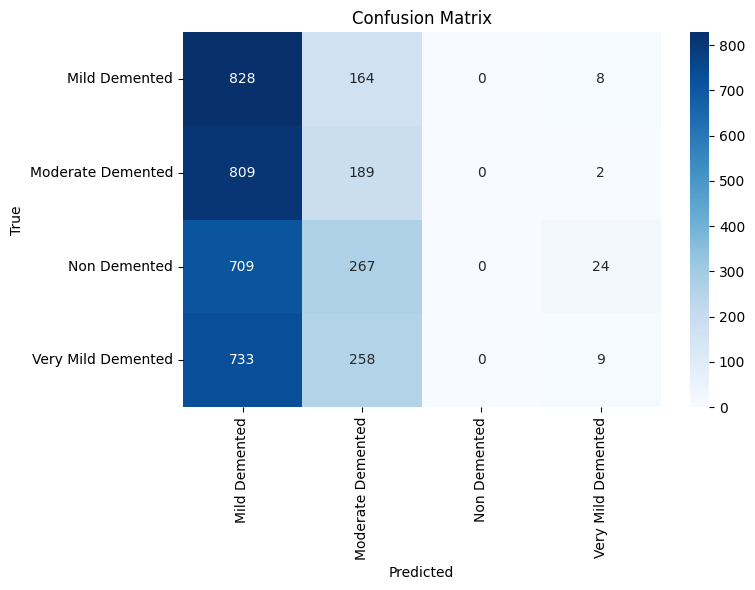

                    precision    recall  f1-score   support

     Mild Demented     0.2689    0.8280    0.4060      1000
 Moderate Demented     0.2153    0.1890    0.2013      1000
      Non Demented     0.0000    0.0000    0.0000      1000
Very Mild Demented     0.2093    0.0090    0.0173      1000

          accuracy                         0.2565      4000
         macro avg     0.1734    0.2565    0.1561      4000
      weighted avg     0.1734    0.2565    0.1561      4000


================ Overall Test Metrics ================
Accuracy               : 0.2565
Precision (Macro)      : 0.1734
Recall (Macro)         : 0.2565
F1-Score (Macro)       : 0.1561

================ Class-wise Metrics ================
             Class  Sensitivity (Recall)  Specificity  Precision  False Positive Rate  False Negative Rate      NPV  F1 Score
     Mild Demented                 0.828     0.249667   0.268918             0.750333                0.172 0.813246  0.405982
 Moderate Demented         

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [19]:
import torch
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()

all_preds = []
all_labels = []

filepaths = test_df['filepath'].values

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device, dtype=torch.long)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)


cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

print(classification_report(
    all_labels,
    all_preds,
    labels=[0,1,2,3],
    target_names=class_names,
    digits=4
))


overall_acc = accuracy_score(all_labels, all_preds)

overall_precision_macro = precision_score(
    all_labels, all_preds, average='macro', zero_division=0
)
overall_recall_macro = recall_score(
    all_labels, all_preds, average='macro', zero_division=0
)
overall_f1_macro = f1_score(
    all_labels, all_preds, average='macro', zero_division=0
)

print("\n================ Overall Test Metrics ================")
print(f"Accuracy               : {overall_acc:.4f}")
print(f"Precision (Macro)      : {overall_precision_macro:.4f}")
print(f"Recall (Macro)         : {overall_recall_macro:.4f}")
print(f"F1-Score (Macro)       : {overall_f1_macro:.4f}")


metrics = []

for i, class_name in enumerate(class_names):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - (TP + FP + FN)

    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    precision   = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    fpr         = FP / (FP + TN) if (FP + TN) > 0 else 0.0
    fnr         = FN / (FN + TP) if (FN + TP) > 0 else 0.0
    npv         = TN / (TN + FN) if (TN + FN) > 0 else 0.0
    f1          = 2 * TP / (2 * TP + FP + FN) if (2*TP + FP + FN) > 0 else 0.0

    metrics.append([
        class_name,
        sensitivity,
        specificity,
        precision,
        fpr,
        fnr,
        npv,
        f1
    ])

metrics_df = pd.DataFrame(metrics, columns=[
    "Class",
    "Sensitivity (Recall)",
    "Specificity",
    "Precision",
    "False Positive Rate",
    "False Negative Rate",
    "NPV",
    "F1 Score"
])

print("\n================ Class-wise Metrics ================")
print(metrics_df.to_string(index=False))


print("\n================ Classification Report ================")
print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4
))


results_df = pd.DataFrame({
    "filepath": filepaths,
    "true_label": [class_names[i] for i in all_labels],
    "pred_label": [class_names[i] for i in all_preds]
})

overall_metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision (Macro)",
        "Recall (Macro)",
        "F1-Score (Macro)"
    ],
    "Value": [
        overall_acc,
        overall_precision_macro,
        overall_recall_macro,
        overall_f1_macro
    ]
})

results_df.to_csv("test_predictions.csv", index=False)
metrics_df.to_csv("test_classwise_metrics.csv", index=False)
overall_metrics_df.to_csv("test_overall_metrics.csv", index=False)

print("\n✅ Predictions saved to 'test_predictions.csv'")
print("✅ Class-wise metrics saved to 'test_classwise_metrics.csv'")
print("✅ Overall metrics saved to 'test_overall_metrics.csv'")

# MobileNetV2

In [20]:
%cd /kaggle/working/Model
%mkdir MobileNetV2

/kaggle/working/Model


In [21]:
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torch
import random

class RandomBiasField:
    def __init__(self, bias_range=0.3):
        self.bias_range = bias_range

    def __call__(self, tensor):
        _, h, w = tensor.shape
        bias = torch.randn(1, h // 16, w // 16)
        bias = torch.nn.functional.interpolate(bias.unsqueeze(0), size=(h, w), mode='bilinear', align_corners=False)[0]
        bias = bias.squeeze(0)
        bias = (bias - bias.min()) / (bias.max() - bias.min() + 1e-8)
        bias = 1.0 + (bias - 0.5) * self.bias_range
        return torch.clamp(tensor * bias, 0, 1)


class AddGaussianNoise:
    def __init__(self, mean=0., std=0.01):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        return torch.clamp(tensor + torch.randn_like(tensor) * self.std + self.mean, 0, 1)


class RandomGammaCorrection:
    def __init__(self, gamma_range=(0.9, 1.1)):
        self.gamma_range = gamma_range

    def __call__(self, tensor):
        gamma = random.uniform(*self.gamma_range)
        return torch.pow(tensor, gamma)


imagenet_normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop((224, 224), scale=(0.9, 1.0)),
    transforms.RandomAffine(degrees=5, translate=(0.02, 0.02)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(),
    RandomBiasField(bias_range=0.25),
    AddGaussianNoise(mean=0., std=0.015),
    RandomGammaCorrection(gamma_range=(0.95, 1.05)),
    imagenet_normalize
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    imagenet_normalize
])

test_transforms = val_transforms

class MRIDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.filepaths = dataframe['filepath'].values
        self.labels = dataframe['label_idx'].values

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.filepaths[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


train_dataset = MRIDataset(train_df, transform=train_transforms)
val_dataset = MRIDataset(val_df, transform=val_transforms)
test_dataset = MRIDataset(test_df, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, drop_last=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

Device: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 122MB/s]


=== Epoch 1/100 ===


Train Loss: 1.1122 | Train Acc: 0.5044 | Val Loss: 1.5977 | Val Acc: 0.3286

=== Epoch 2/100 ===
Train Loss: 0.9771 | Train Acc: 0.5732 | Val Loss: 1.5469 | Val Acc: 0.3247

=== Epoch 3/100 ===
Train Loss: 0.9315 | Train Acc: 0.5881 | Val Loss: 1.6303 | Val Acc: 0.3222

=== Epoch 4/100 ===
Train Loss: 0.9032 | Train Acc: 0.6037 | Val Loss: 1.5803 | Val Acc: 0.3367

=== Epoch 5/100 ===
Train Loss: 0.8776 | Train Acc: 0.6191 | Val Loss: 1.5809 | Val Acc: 0.3344

=== Epoch 6/100 ===
Train Loss: 0.8584 | Train Acc: 0.6229 | Val Loss: 1.4695 | Val Acc: 0.3825

=== Epoch 7/100 ===
Train Loss: 0.8515 | Train Acc: 0.6280 | Val Loss: 1.4286 | Val Acc: 0.3833

=== Epoch 8/100 ===
Train Loss: 0.8361 | Train Acc: 0.6352 | Val Loss: 1.4262 | Val Acc: 0.3608

=== Epoch 9/100 ===
Train Loss: 0.8277 | Train Acc: 0.6374 | Val Loss: 1.5740 | Val Acc: 0.3392

=== Epoch 10/100 ===
Train Loss: 0.8165 | Train Acc: 0.6451 | Val Loss: 1.4783 | Val Acc: 0.3628

=== Epoch 11/100 ===
Train Loss: 0.8041 | Train A

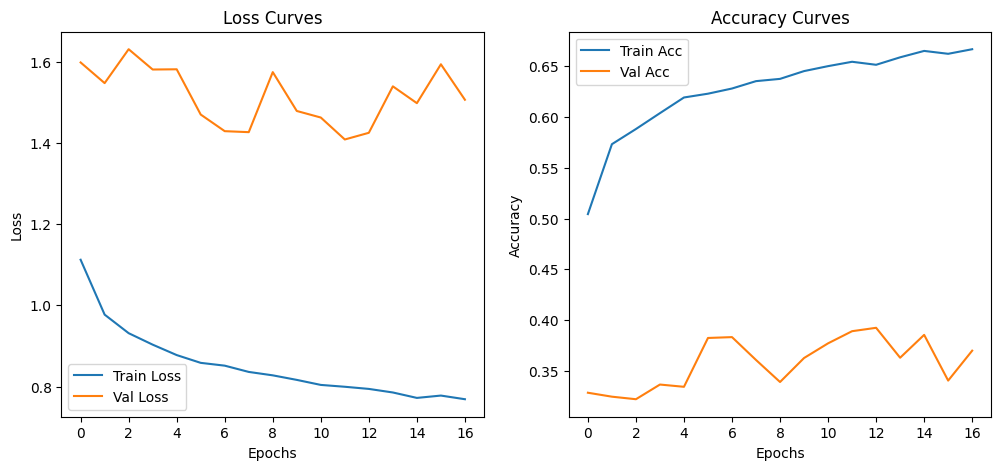

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
from torchvision import models

num_classes = 4
EPOCHS = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_PATH = "/kaggle/working/Model/MobileNetV2/best_mobilenetv2_full.pth"
SAVE_WEIGHTS_PATH = "/kaggle/working/Model/MobileNetV2/best_mobilenetv2_weights.pth"

print("Device:", device)

base_model = models.mobilenet_v2(pretrained=True)

for param in base_model.parameters():
    param.requires_grad = False

class CustomMobileNetV2(nn.Module):
    def __init__(self, backbone, num_classes):
        super().__init__()

        self.backbone = backbone
        
        self.backbone.classifier = nn.Identity()

        in_features = 1280

        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Dropout(0.4),

            nn.Linear(in_features, 512, bias=False),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),

            nn.Linear(512, 128, bias=False),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(128),
            nn.Dropout(0.2),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.backbone.features(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)

        return x

model = CustomMobileNetV2(base_model, num_classes=num_classes)
model = model.float().to(device)

criterion = nn.CrossEntropyLoss()
l2_layers = [model.classifier[1], model.classifier[5]]
params_with_l2 = [p for layer in l2_layers for p in layer.parameters()]
params_with_l2_ids = set(id(p) for p in params_with_l2)
params_without_l2 = [p for p in model.parameters() if id(p) not in params_with_l2_ids]

optimizer = optim.Adam([
    {'params': params_with_l2, 'weight_decay': 1e-4},
    {'params': params_without_l2, 'weight_decay': 0.0}
], lr=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6
)

class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-3, save_path=SAVE_PATH, save_weights_path=SAVE_WEIGHTS_PATH):
        self.patience = patience
        self.min_delta = min_delta
        self.save_path = save_path
        self.save_weights_path = save_weights_path
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model, self.save_path)
            torch.save(model.state_dict(), self.save_weights_path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

early_stopping = EarlyStopping()


from torch.amp import autocast, GradScaler
scaler = GradScaler()


train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(EPOCHS):
    print(f"\n=== Epoch {epoch+1}/{EPOCHS} ===")
    model.train()
    running_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device, dtype=torch.long)
        optimizer.zero_grad()

        with autocast(device_type=device.type):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:  # val_loader must be defined
            images, labels = images.to(device), labels.to(device, dtype=torch.long)
            with autocast(device_type=device.type):
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    scheduler.step(val_loss)
    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print("⏹ Early stopping triggered!")
        break

model.load_state_dict(torch.load(SAVE_WEIGHTS_PATH, map_location=device))
model.to(device)
print("✅ Loaded best DS-ViT model weights.")

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend(); plt.title("Loss Curves")

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.legend(); plt.title("Accuracy Curves")
plt.show()

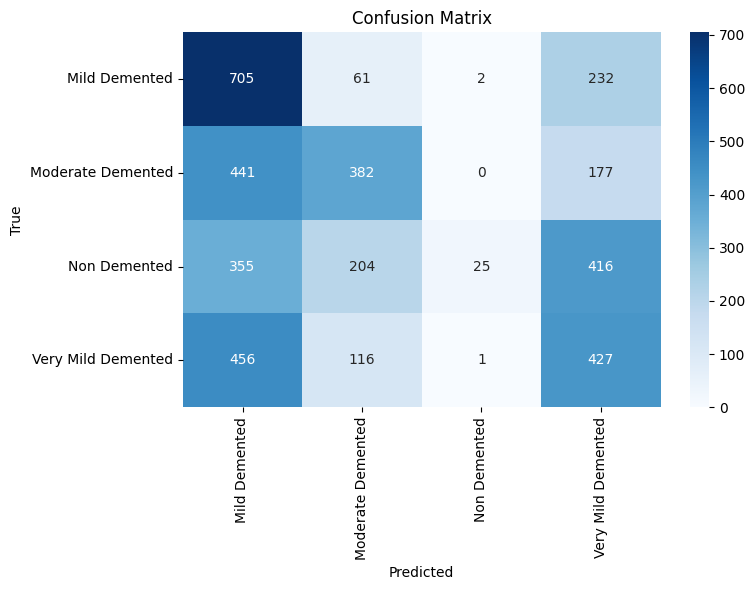


================ Overall Test Metrics ================
Accuracy               : 0.3847
Precision (Macro)      : 0.5237
Recall (Macro)         : 0.3847
F1-Score (Macro)       : 0.3345

================ Class-wise Metrics ================
             Class  Sensitivity (Recall)  Specificity  Precision  False Positive Rate  False Negative Rate      NPV  F1 Score
     Mild Demented                 0.705     0.582667   0.360245             0.417333                0.295 0.855605  0.476835
 Moderate Demented                 0.382     0.873000   0.500655             0.127000                0.618 0.809082  0.433352
      Non Demented                 0.025     0.999000   0.892857             0.001000                0.975 0.754532  0.048638
Very Mild Demented                 0.427     0.725000   0.341054             0.275000                0.573 0.791485  0.379218

================ Classification Report ================
                    precision    recall  f1-score   support

     Mild Deme

In [23]:
import torch
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()

all_preds = []
all_labels = []

filepaths = test_df['filepath'].values

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device, dtype=torch.long)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)


cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


overall_acc = accuracy_score(all_labels, all_preds)

overall_precision_macro = precision_score(
    all_labels, all_preds, average='macro', zero_division=0
)
overall_recall_macro = recall_score(
    all_labels, all_preds, average='macro', zero_division=0
)
overall_f1_macro = f1_score(
    all_labels, all_preds, average='macro', zero_division=0
)

print("\n================ Overall Test Metrics ================")
print(f"Accuracy               : {overall_acc:.4f}")
print(f"Precision (Macro)      : {overall_precision_macro:.4f}")
print(f"Recall (Macro)         : {overall_recall_macro:.4f}")
print(f"F1-Score (Macro)       : {overall_f1_macro:.4f}")


metrics = []

for i, class_name in enumerate(class_names):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - (TP + FP + FN)

    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    precision   = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    fpr         = FP / (FP + TN) if (FP + TN) > 0 else 0.0
    fnr         = FN / (FN + TP) if (FN + TP) > 0 else 0.0
    npv         = TN / (TN + FN) if (TN + FN) > 0 else 0.0
    f1          = 2 * TP / (2 * TP + FP + FN) if (2*TP + FP + FN) > 0 else 0.0

    metrics.append([
        class_name,
        sensitivity,
        specificity,
        precision,
        fpr,
        fnr,
        npv,
        f1
    ])

metrics_df = pd.DataFrame(metrics, columns=[
    "Class",
    "Sensitivity (Recall)",
    "Specificity",
    "Precision",
    "False Positive Rate",
    "False Negative Rate",
    "NPV",
    "F1 Score"
])

print("\n================ Class-wise Metrics ================")
print(metrics_df.to_string(index=False))


print("\n================ Classification Report ================")
print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4
))


results_df = pd.DataFrame({
    "filepath": filepaths,
    "true_label": [class_names[i] for i in all_labels],
    "pred_label": [class_names[i] for i in all_preds]
})

overall_metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision (Macro)",
        "Recall (Macro)",
        "F1-Score (Macro)"
    ],
    "Value": [
        overall_acc,
        overall_precision_macro,
        overall_recall_macro,
        overall_f1_macro
    ]
})

results_df.to_csv("test_predictions.csv", index=False)
metrics_df.to_csv("test_classwise_metrics.csv", index=False)
overall_metrics_df.to_csv("test_overall_metrics.csv", index=False)

print("\n✅ Predictions saved to 'test_predictions.csv'")
print("✅ Class-wise metrics saved to 'test_classwise_metrics.csv'")
print("✅ Overall metrics saved to 'test_overall_metrics.csv'")